# ITCS 6169/8169 — Assignment 1: The CNN Challenge
## 16-class scene recognition from 2,400 training images

This notebook starts from the provided starter (`TNet`, ~50% accuracy) and improves it through a sequence of **controlled experiments**. Each experiment changes one main factor relative to the previous one, and every decision is made on a **stratified validation split** carved out of `data/train`. The labeled `data/test` set is touched **exactly once**, at the very end, for the selected model.

**Questions investigated**

1. Is the starter limited by architecture capacity? → deeper CNN with BatchNorm
2. Is the model overfitting? Does augmentation help?
3. Does the training strategy matter (AdamW + weight decay, one-cycle LR, label smoothing)?
4. Does ImageNet initialization help substantially? (linear probe vs. full fine-tuning, and same architecture from random init)
5. Can a smaller/more efficient CNN (EfficientNet-B0) match ResNet-18?
6. Does higher input resolution (160 → 224) justify its compute?
7. Which classes are hardest?

**Compute note.** All runs below were executed on a **CPU-only machine (2 cores)**, so epoch budgets are deliberately modest. On a GPU (e.g. Colab) the same notebook runs much faster.

In [1]:
# Core imports
from pathlib import Path
import os, random, time, copy, json, math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
import timm
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__} | timm {timm.__version__} | "
      f"numpy {np.__version__} | scikit-learn {sklearn.__version__}")
print(f"CUDA available: {torch.cuda.is_available()} | CPU threads: {torch.get_num_threads()}")

PyTorch 2.14.1+cu130 | torchvision 0.29.1+cu130 | timm 1.0.30 | numpy 2.5.3 | scikit-learn 1.9.1
CUDA available: False | CPU threads: 2


## 1. Paths, seed, device

`QUICK=1` (environment variable) shrinks every epoch budget to 1 for a fast smoke test of the whole pipeline. The reported results use `QUICK=0`.

**Resume support.** Every finished run saves its best checkpoint (`runs/<tag>.pt`) and per-epoch log (`runs/<tag>.json`). If the notebook is re-executed, finished runs are loaded and their logged curves replayed instead of retraining (the full sequence takes ~2.5 h on CPU). A run that is interrupted mid-way resumes from its last completed epoch (`runs/<tag>.partial.pt`). Set `FORCE_RETRAIN=1` to retrain everything from scratch.

In [2]:
PROJECT_ROOT = Path('.')            # change if your data lives elsewhere (e.g. Google Drive)
DATA_ROOT  = PROJECT_ROOT / 'data'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT  = DATA_ROOT / 'test'
TEST2_ROOT = DATA_ROOT / 'test2'    # unlabeled images -> predictions CSV at the end
RUN_DIR    = PROJECT_ROOT / 'runs'; RUN_DIR.mkdir(exist_ok=True)
WEIGHT_DIR = PROJECT_ROOT / 'weights'; WEIGHT_DIR.mkdir(exist_ok=True)

QUICK = os.environ.get('QUICK', '0') == '1'
FORCE_RETRAIN = os.environ.get('FORCE_RETRAIN', '0') == '1'   # 1 = ignore finished runs in runs/ and retrain everything
if QUICK:
    RUN_DIR = PROJECT_ROOT / 'runs_quick'; RUN_DIR.mkdir(exist_ok=True)   # keep smoke-test files separate
def E(n):                           # epoch budget helper
    return 1 if QUICK else n

SEED = 0
def set_random_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 0 if device.type == 'cpu' else 2
print('device:', device, '| QUICK mode:', QUICK)

device: cpu | QUICK mode: False


## 2. Data inspection — an important finding before any training

Before training anything, I checked the image modes and sizes. **All 15 scene classes are grayscale (`L`), but every `Flower` image is RGB** (in train, test and test2). A model given colour input could therefore learn the shortcut *"has colour ⇒ Flower"* rather than learning what flowers look like. That would inflate accuracy for one class without learning anything transferable.

**Decision:** convert *every* image to grayscale. For ImageNet-pretrained CNNs the single channel is replicated to 3 channels.

In [3]:
from collections import Counter
mode_counts = Counter()
size_counts = Counter()
for split in ['train', 'test']:
    for p in sorted((DATA_ROOT / split).glob('*/*.jpg')):
        with Image.open(p) as im:
            mode_counts[(split, p.parent.name if im.mode == 'RGB' else '(15 scene classes)', im.mode)] += 1
            size_counts[im.size] += 1
for k, v in sorted(mode_counts.items()):
    print(f'{k}: {v}')
print('Most common image sizes:', size_counts.most_common(5))

('test', '(15 scene classes)', 'L'): 375
('test', 'Flower', 'RGB'): 25
('train', '(15 scene classes)', 'L'): 2250
('train', 'Flower', 'RGB'): 150
Most common image sizes: [((256, 256), 1400), ((293, 220), 252), ((330, 220), 220), ((220, 293), 49), ((666, 500), 38)]


### Loading, caching and a stratified train/validation split

* Images are decoded once, converted to grayscale and resized so the **shorter side is 256 px**, then cached in RAM (the dataset is tiny), which keeps CPU training fast.
* The starter used `random_split`; I use a **stratified 80/20 split** (seed 0) so each class has exactly 30 validation images (1,920 train / 480 val). With only 30 images per class, a random split can easily give some classes noticeably fewer validation images.
* The labeled test set (400 images, 25 per class) is held out until the end.

In [4]:
def resize_short(img, short=256):
    w, h = img.size
    s = short / min(w, h)
    if s < 1:   # only downscale large images (the RGB flower photos are ~500x666)
        img = img.resize((round(w * s), round(h * s)), Image.BICUBIC)
    return img

def load_folder(root):
    classes = sorted(d.name for d in root.iterdir() if d.is_dir())
    imgs, labels, paths = [], [], []
    for ci, c in enumerate(classes):
        for p in sorted((root / c).glob('*.jpg')):
            with Image.open(p) as im:
                imgs.append(resize_short(im.convert('L')))
            labels.append(ci); paths.append(str(p))
    return classes, imgs, np.array(labels), paths

class_names, all_imgs, all_labels, all_paths = load_folder(TRAIN_ROOT)
test_classes, test_imgs, test_labels, test_paths = load_folder(TEST_ROOT)
assert test_classes == class_names
num_classes = len(class_names)

idx = np.arange(len(all_imgs))
tr_idx, va_idx = train_test_split(idx, test_size=0.20, stratify=all_labels, random_state=SEED)
tr_imgs, tr_labels = [all_imgs[i] for i in tr_idx], all_labels[tr_idx]
va_imgs, va_labels = [all_imgs[i] for i in va_idx], all_labels[va_idx]

print(f'Classes ({num_classes}): {class_names}')
print(f'Train {len(tr_imgs)} | Val {len(va_imgs)} | Test {len(test_imgs)}')
print('Val images per class:', np.bincount(va_labels))

Classes (16): ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Train 1920 | Val 480 | Test 400
Val images per class: [30 30 30 30 30 30 30 30 30 30 30 30 30 30 30 30]


In [5]:
class CachedDataset(Dataset):
    def __init__(self, imgs, labels, transform):
        self.imgs, self.labels, self.transform = imgs, labels, transform
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, i):
        return self.transform(self.imgs[i]), int(self.labels[i])

# --- transforms ------------------------------------------------------------
GRAY_MEAN, GRAY_STD = 0.5, 0.5                    # starter-style normalization for 1-channel scratch models
IMNET_MEAN, IMNET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

class ToThreeChannel:
    def __call__(self, x):
        return x.expand(3, -1, -1)

def make_transforms(size, augment, pretrained):
    norm = ([ToThreeChannel(), transforms.Normalize(IMNET_MEAN, IMNET_STD)] if pretrained
            else [transforms.Normalize([GRAY_MEAN], [GRAY_STD])])
    if augment:
        tf = [transforms.RandomResizedCrop(size, scale=(0.35, 1.0), ratio=(3/4, 4/3)),
              transforms.RandomHorizontalFlip(),
              transforms.ColorJitter(brightness=0.3, contrast=0.3)]
    else:
        tf = [transforms.Resize((size, size))]       # squash full scene (keeps all context)
    return transforms.Compose(tf + [transforms.ToTensor()] + norm)

def eval_transform(size, pretrained):
    return make_transforms(size, augment=False, pretrained=pretrained)

def make_loaders(size, augment, pretrained, batch_size=64):
    g = torch.Generator().manual_seed(SEED)
    tr = CachedDataset(tr_imgs, tr_labels, make_transforms(size, augment, pretrained))
    va = CachedDataset(va_imgs, va_labels, eval_transform(size, pretrained))
    return (DataLoader(tr, batch_size=batch_size, shuffle=True, generator=g, num_workers=NUM_WORKERS),
            DataLoader(va, batch_size=128, shuffle=False, num_workers=NUM_WORKERS))

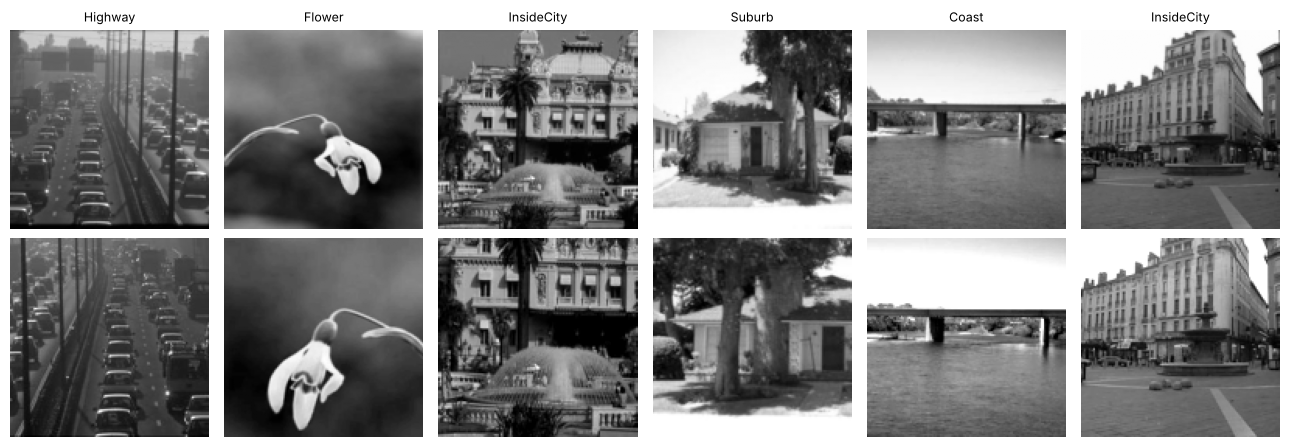

In [6]:
# Visual sanity check of the augmentation pipeline (top: eval transform, bottom: random augmentations)
tf_eval, tf_aug = make_transforms(128, False, False), make_transforms(128, True, False)
fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))
for j, i in enumerate(np.linspace(0, len(tr_imgs) - 1, 6).astype(int)):
    axes[0, j].imshow(tf_eval(tr_imgs[i])[0] * GRAY_STD + GRAY_MEAN, cmap='gray'); axes[0, j].set_title(class_names[tr_labels[i]], fontsize=9)
    axes[1, j].imshow(tf_aug(tr_imgs[i])[0] * GRAY_STD + GRAY_MEAN, cmap='gray')
for a in axes.flat: a.axis('off')
plt.tight_layout(); plt.show()

## 3. Shared training / evaluation utilities

One training function is used for every experiment so that comparisons are controlled. It supports:

* Adam / AdamW (optionally separate learning rates for a pretrained backbone and a new head),
* constant LR or **one-cycle** (linear warm-up + cosine decay, stepped per iteration),
* label smoothing,
* **model selection by best validation accuracy** (as in the starter), and logging of train/val loss + accuracy and wall-clock time.

In [7]:
@torch.inference_mode()
def evaluate(model, loader, tta=False):
    model.eval()
    correct = total = 0; loss_sum = 0.0; all_logits = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        if tta:   # average with horizontally-flipped view
            logits = (logits.softmax(1) + model(torch.flip(x, dims=[3])).softmax(1)).log()
        loss_sum += F.cross_entropy(logits, y, reduction='sum').item()
        correct += (logits.argmax(1) == y).sum().item(); total += y.numel()
        all_logits.append(logits.cpu())
    return loss_sum / total, correct / total, torch.cat(all_logits)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def train_model(model, train_loader, val_loader, epochs, lr=2e-3, opt='adam', weight_decay=0.0,
                schedule='constant', label_smoothing=0.0, head_lr_mult=None, tag='run'):
    model = model.to(device)
    ckpt, meta = RUN_DIR / f'{tag}.pt', RUN_DIR / f'{tag}.json'
    if ckpt.exists() and meta.exists() and not (QUICK or FORCE_RETRAIN):
        # Resume support: reuse a finished run instead of retraining (set FORCE_RETRAIN=1 to retrain).
        summary = json.load(open(meta)); h = summary['hist']
        model.load_state_dict(torch.load(ckpt, map_location=device))
        print(f'[{tag}] finished run found in {ckpt} -> loading checkpoint and replaying its training log')
        for ep in range(len(h['val_acc'])):
            print(f"[{tag}] ep {ep+1:02d}/{len(h['val_acc'])} | train loss {h['train_loss'][ep]:.3f} acc {h['train_acc'][ep]:.3f} | "
                  f"val loss {h['val_loss'][ep]:.3f} acc {h['val_acc'][ep]:.3f}")
        print(f"[{tag}] best val acc {summary['best_val_acc']:.4f} at epoch {summary['best_epoch']} | {summary['train_time_min']:.1f} min")
        return model, summary
    if head_lr_mult is not None:     # pretrained backbone: smaller LR than the freshly-initialised head
        head = list(model.get_classifier().parameters()); head_ids = {id(p) for p in head}
        body = [p for p in model.parameters() if id(p) not in head_ids and p.requires_grad]
        groups = [{'params': body, 'lr': lr}, {'params': head, 'lr': lr * head_lr_mult}]
    else:
        groups = [{'params': [p for p in model.parameters() if p.requires_grad], 'lr': lr}]
    if opt == 'adam':
        optimizer = optim.Adam(groups, lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.AdamW(groups, lr=lr, weight_decay=weight_decay)
    scheduler = None
    if schedule == 'onecycle':
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=[g['lr'] for g in groups], epochs=epochs,
            steps_per_epoch=len(train_loader), pct_start=0.15, anneal_strategy='cos')
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    hist = {k: [] for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc']}
    best_acc, best_state, best_epoch = -1, None, -1
    start_ep, elapsed0 = 1, 0.0
    partial = RUN_DIR / f'{tag}.partial.pt'
    if partial.exists() and not (QUICK or FORCE_RETRAIN):   # resume an interrupted run from its last finished epoch
        p = torch.load(partial, map_location=device)
        model.load_state_dict(p['model']); optimizer.load_state_dict(p['optimizer'])
        if scheduler: scheduler.load_state_dict(p['scheduler'])
        hist, best_acc, best_state, best_epoch = p['hist'], p['best_acc'], p['best_state'], p['best_epoch']
        start_ep, elapsed0 = p['epoch'] + 1, p['elapsed']
        print(f'[{tag}] resuming interrupted run after epoch {p["epoch"]}')
    t0 = time.time() - elapsed0
    for ep in range(start_ep, epochs + 1):
        model.train(); tl = tc = tn = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x); loss = criterion(logits, y)
            loss.backward(); optimizer.step()
            if scheduler: scheduler.step()
            tl += loss.item() * y.numel(); tc += (logits.argmax(1) == y).sum().item(); tn += y.numel()
        vl, va, _ = evaluate(model, val_loader)
        for k, v in zip(hist, [tl / tn, tc / tn, vl, va]): hist[k].append(v)
        if va > best_acc:
            best_acc, best_epoch, best_state = va, ep, copy.deepcopy(model.state_dict())
        print(f'[{tag}] ep {ep:02d}/{epochs} | train loss {tl/tn:.3f} acc {tc/tn:.3f} | '
              f'val loss {vl:.3f} acc {va:.3f} | {time.time()-t0:.0f}s')
        torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                    'scheduler': scheduler.state_dict() if scheduler else None, 'hist': hist, 'best_acc': best_acc,
                    'best_state': best_state, 'best_epoch': best_epoch, 'epoch': ep, 'elapsed': time.time() - t0}, partial)
    model.load_state_dict(best_state)
    train_time = time.time() - t0
    print(f'[{tag}] best val acc {best_acc:.4f} at epoch {best_epoch} | {train_time/60:.1f} min')
    summary = {'hist': hist, 'best_val_acc': best_acc, 'best_epoch': best_epoch,
               'train_time_min': train_time / 60, 'final_train_acc': hist['train_acc'][-1]}
    torch.save(best_state, ckpt); json.dump(summary, open(meta, 'w'))
    partial.unlink(missing_ok=True)
    return model, summary

RESULTS = {}   # experiment name -> summary dict
def record(name, summary, model, notes, **extra):
    RESULTS[name] = {**summary, 'params_M': count_params(model) / 1e6, 'notes': notes, **extra}
    json.dump({k: {kk: vv for kk, vv in v.items()} for k, v in RESULTS.items()},
              open(RUN_DIR / 'results.json', 'w'), indent=1)

def plot_history(summary, title):
    h = summary['hist']; ep = range(1, len(h['train_loss']) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
    ax[0].plot(ep, h['train_loss'], label='train'); ax[0].plot(ep, h['val_loss'], label='val'); ax[0].set_title(f'{title}: loss')
    ax[1].plot(ep, h['train_acc'], label='train'); ax[1].plot(ep, h['val_acc'], label='val'); ax[1].set_title(f'{title}: accuracy')
    for a in ax: a.set_xlabel('epoch'); a.legend(); a.grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. Experiment 0 — Starter baseline (TNet)

Reproduced exactly as provided: grayscale 64×64, one conv layer (16 filters) + 4×4 max-pool + linear layer, Adam (lr 2e-3), 20 epochs, no augmentation. The only change is the stratified split.

[E0_tnet] finished run found in runs/E0_tnet.pt -> loading checkpoint and replaying its training log
[E0_tnet] ep 01/20 | train loss 2.580 acc 0.198 | val loss 2.292 acc 0.277
[E0_tnet] ep 02/20 | train loss 2.019 acc 0.399 | val loss 2.049 acc 0.338
[E0_tnet] ep 03/20 | train loss 1.676 acc 0.490 | val loss 1.877 acc 0.406
[E0_tnet] ep 04/20 | train loss 1.372 acc 0.586 | val loss 1.809 acc 0.408
[E0_tnet] ep 05/20 | train loss 1.156 acc 0.653 | val loss 1.737 acc 0.463
[E0_tnet] ep 06/20 | train loss 0.963 acc 0.723 | val loss 1.721 acc 0.483
[E0_tnet] ep 07/20 | train loss 0.804 acc 0.788 | val loss 1.761 acc 0.463
[E0_tnet] ep 08/20 | train loss 0.679 acc 0.816 | val loss 1.800 acc 0.446
[E0_tnet] ep 09/20 | train loss 0.576 acc 0.863 | val loss 1.763 acc 0.469
[E0_tnet] ep 10/20 | train loss 0.492 acc 0.897 | val loss 1.880 acc 0.442
[E0_tnet] ep 11/20 | train loss 0.438 acc 0.907 | val loss 1.873 acc 0.473
[E0_tnet] ep 12/20 | train loss 0.374 acc 0.926 | val loss 1.936 acc 0.454

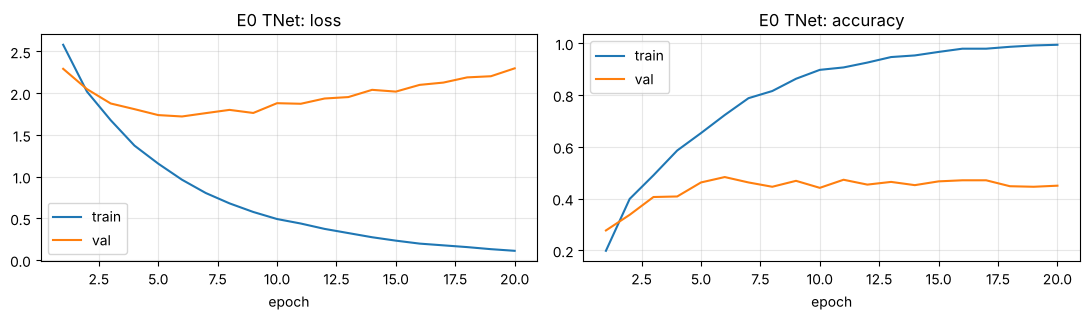

In [8]:
class TNet(nn.Module):
    # The starter's deliberately small CNN (unchanged)
    def __init__(self, num_classes=16):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 16, kernel_size=3), nn.ReLU(inplace=True),
                                      nn.MaxPool2d(kernel_size=4, stride=4))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(16 * 15 * 15, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

set_random_seed(SEED)
tl, vl = make_loaders(64, augment=False, pretrained=False)
m = TNet(num_classes)
m, s = train_model(m, tl, vl, epochs=E(20), lr=2e-3, opt='adam', tag='E0_tnet')
record('E0 Starter TNet (64px)', s, m, 'Starter baseline', res=64, pretrained='no', aug='no')
plot_history(s, 'E0 TNet')

## 5. Experiment 1 — A deeper CNN with BatchNorm (architecture only)

**Hypothesis.** TNet has a single conv layer with a 3×3 receptive field; a scene class (e.g. *Highway* vs *Street*) depends on layout over large regions, so the starter is **capacity/receptive-field limited** (it underfits *and* overfits: a huge 3,600×16 linear layer on top of tiny local features).

**Change.** `SceneCNN`: 4 stages of [conv3×3-BN-ReLU]×2 + max-pool (32→64→128→256 channels), global average pooling, dropout 0.3, linear head (~1.2M parameters, far fewer in the classifier than TNet). Everything else identical to E0 (64 px, Adam 2e-3 constant, no augmentation); epochs increased to 40 for all scratch experiments, and the best-validation epoch is kept.

SceneCNN parameters: 1,176,752


[E1_scenecnn] finished run found in runs/E1_scenecnn.pt -> loading checkpoint and replaying its training log
[E1_scenecnn] ep 01/40 | train loss 2.452 acc 0.184 | val loss 3.036 acc 0.123
[E1_scenecnn] ep 02/40 | train loss 1.927 acc 0.345 | val loss 2.252 acc 0.246
[E1_scenecnn] ep 03/40 | train loss 1.611 acc 0.455 | val loss 2.390 acc 0.362
[E1_scenecnn] ep 04/40 | train loss 1.361 acc 0.537 | val loss 1.651 acc 0.477
[E1_scenecnn] ep 05/40 | train loss 1.138 acc 0.611 | val loss 1.324 acc 0.558
[E1_scenecnn] ep 06/40 | train loss 0.969 acc 0.674 | val loss 1.888 acc 0.417
[E1_scenecnn] ep 07/40 | train loss 0.911 acc 0.696 | val loss 1.326 acc 0.544
[E1_scenecnn] ep 08/40 | train loss 0.810 acc 0.721 | val loss 1.013 acc 0.667
[E1_scenecnn] ep 09/40 | train loss 0.700 acc 0.769 | val loss 1.070 acc 0.665
[E1_scenecnn] ep 10/40 | train loss 0.637 acc 0.785 | val loss 0.868 acc 0.706
[E1_scenecnn] ep 11/40 | train loss 0.573 acc 0.806 | val loss 1.200 acc 0.629
[E1_scenecnn] ep 12/40

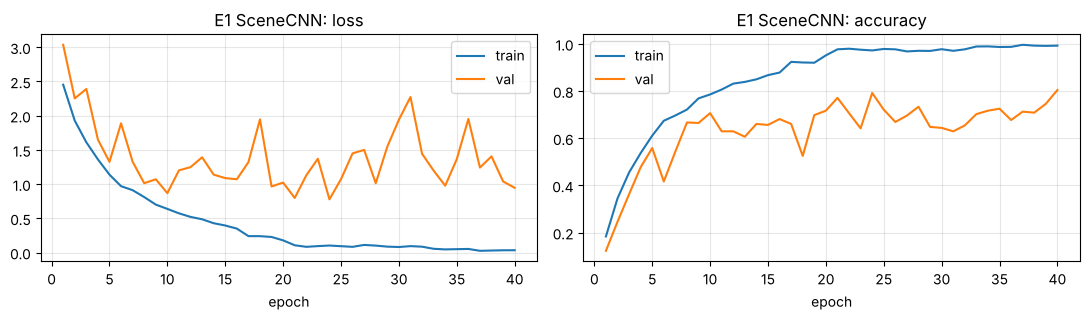

In [9]:
def conv_block(cin, cout):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.MaxPool2d(2))

class SceneCNN(nn.Module):
    def __init__(self, num_classes=16, in_ch=1, widths=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        layers, c = [], in_ch
        for w in widths:
            layers.append(conv_block(c, w)); c = w
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(c, num_classes))
    def forward(self, x):
        return self.head(self.pool(self.features(x)))

set_random_seed(SEED)
tl, vl = make_loaders(64, augment=False, pretrained=False)
m = SceneCNN(num_classes)
print(f'SceneCNN parameters: {count_params(m):,}')
m, s = train_model(m, tl, vl, epochs=E(40), lr=2e-3, opt='adam', tag='E1_scenecnn')
record('E1 SceneCNN (BN, GAP)', s, m, 'Deeper CNN, same recipe as E0', res=64, pretrained='no', aug='no')
plot_history(s, 'E1 SceneCNN')

## 6. Experiment 2 — + Data augmentation

**Hypothesis.** With only 120 training images per class, a 1.2M-parameter CNN will memorise the training set (train accuracy → ~100% while validation loss rises). Label-preserving augmentation for scenes should regularise it: random-resized crops (scale 0.35–1, scenes are still recognisable from a sub-region), horizontal flips (scenes are left/right symmetric — but *not* vertical flips, since sky-on-top is a strong cue), and brightness/contrast jitter.

**Change.** Only the training transform; architecture, optimizer and epochs as in E1.

[E2_scenecnn_aug] finished run found in runs/E2_scenecnn_aug.pt -> loading checkpoint and replaying its training log
[E2_scenecnn_aug] ep 01/40 | train loss 2.663 acc 0.142 | val loss 4.000 acc 0.065
[E2_scenecnn_aug] ep 02/40 | train loss 2.290 acc 0.227 | val loss 2.324 acc 0.237
[E2_scenecnn_aug] ep 03/40 | train loss 1.923 acc 0.345 | val loss 1.888 acc 0.348
[E2_scenecnn_aug] ep 04/40 | train loss 1.664 acc 0.444 | val loss 1.552 acc 0.467
[E2_scenecnn_aug] ep 05/40 | train loss 1.509 acc 0.484 | val loss 1.493 acc 0.517
[E2_scenecnn_aug] ep 06/40 | train loss 1.382 acc 0.527 | val loss 2.582 acc 0.281
[E2_scenecnn_aug] ep 07/40 | train loss 1.272 acc 0.565 | val loss 1.229 acc 0.577
[E2_scenecnn_aug] ep 08/40 | train loss 1.169 acc 0.609 | val loss 1.342 acc 0.552
[E2_scenecnn_aug] ep 09/40 | train loss 1.120 acc 0.622 | val loss 1.173 acc 0.600
[E2_scenecnn_aug] ep 10/40 | train loss 1.042 acc 0.640 | val loss 1.231 acc 0.598
[E2_scenecnn_aug] ep 11/40 | train loss 1.041 acc 0.6

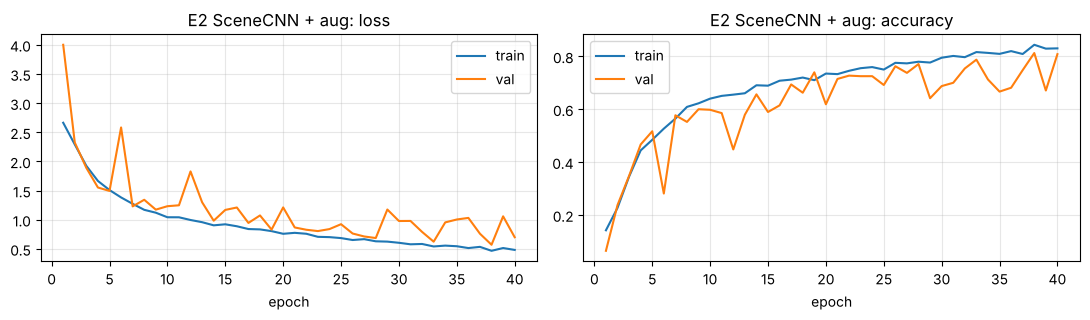

In [10]:
set_random_seed(SEED)
tl, vl = make_loaders(64, augment=True, pretrained=False)
m = SceneCNN(num_classes)
m, s = train_model(m, tl, vl, epochs=E(40), lr=2e-3, opt='adam', tag='E2_scenecnn_aug')
record('E2 + augmentation', s, m, 'RandomResizedCrop + hflip + jitter', res=64, pretrained='no', aug='yes')
plot_history(s, 'E2 SceneCNN + aug')

## 7. Experiment 3 — + Training strategy (AdamW, weight decay, one-cycle LR, label smoothing)

**Hypothesis.** A constant LR of 2e-3 makes the validation curve noisy and the final weights sit in a high-LR regime. A one-cycle schedule (warm-up then cosine decay to ~0) should let the model settle into a better minimum; decoupled weight decay (AdamW, 0.05) and label smoothing (0.1) add regularisation that matters with so little data.

**Change.** Optimizer/schedule/loss only (same model, data and augmentation as E2).

[E3_scenecnn_aug_strategy] finished run found in runs/E3_scenecnn_aug_strategy.pt -> loading checkpoint and replaying its training log
[E3_scenecnn_aug_strategy] ep 01/40 | train loss 2.642 acc 0.156 | val loss 3.420 acc 0.062
[E3_scenecnn_aug_strategy] ep 02/40 | train loss 2.265 acc 0.300 | val loss 2.143 acc 0.256
[E3_scenecnn_aug_strategy] ep 03/40 | train loss 1.985 acc 0.406 | val loss 1.942 acc 0.421
[E3_scenecnn_aug_strategy] ep 04/40 | train loss 1.832 acc 0.468 | val loss 1.867 acc 0.419
[E3_scenecnn_aug_strategy] ep 05/40 | train loss 1.799 acc 0.494 | val loss 3.091 acc 0.233
[E3_scenecnn_aug_strategy] ep 06/40 | train loss 1.716 acc 0.536 | val loss 2.131 acc 0.346
[E3_scenecnn_aug_strategy] ep 07/40 | train loss 1.607 acc 0.577 | val loss 1.611 acc 0.454
[E3_scenecnn_aug_strategy] ep 08/40 | train loss 1.539 acc 0.610 | val loss 1.273 acc 0.573
[E3_scenecnn_aug_strategy] ep 09/40 | train loss 1.462 acc 0.638 | val loss 1.249 acc 0.577
[E3_scenecnn_aug_strategy] ep 10/40 |

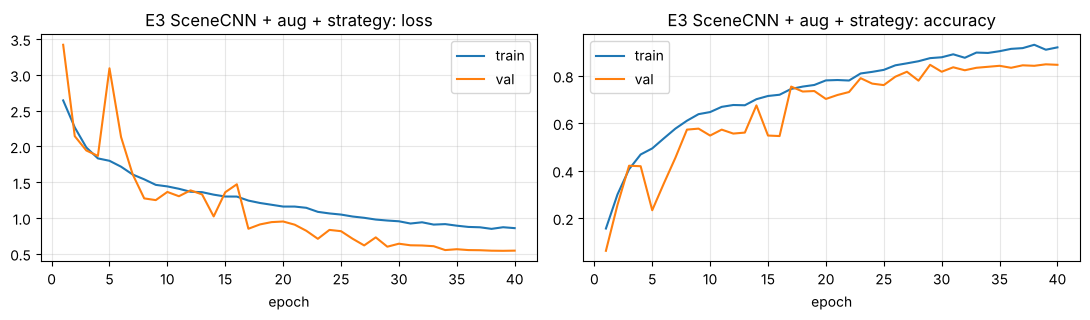

In [11]:
set_random_seed(SEED)
tl, vl = make_loaders(64, augment=True, pretrained=False)
m = SceneCNN(num_classes)
m, s = train_model(m, tl, vl, epochs=E(40), lr=3e-3, opt='adamw', weight_decay=0.05,
                   schedule='onecycle', label_smoothing=0.1, tag='E3_scenecnn_aug_strategy')
record('E3 + AdamW/one-cycle/LS', s, m, 'AdamW wd=0.05, one-cycle (max 3e-3), LS=0.1', res=64, pretrained='no', aug='yes')
plot_history(s, 'E3 SceneCNN + aug + strategy')
scratch_best = m

## 8. Experiments 4–5 — Does ImageNet initialization help?

Pretrained network used: **ResNet-18**, weights `resnet18.a1_in1k` from `timm` (trained on **ImageNet-1k** only, "ResNet Strikes Back" A1 recipe). The 1000-way classifier is replaced with a new 16-way linear layer. Grayscale images are replicated to 3 channels and normalised with ImageNet statistics. Input resolution 160 px (CPU budget; 224 tested later).

* **E4 – Linear probe:** all convolutional weights frozen; only the new linear head is trained (on fixed features of un-augmented images). Measures how good *off-the-shelf* ImageNet features are for these scenes.
* **E5 – Full fine-tuning:** *all* parameters are fine-tuned, using the E3 recipe (augmentation, AdamW, one-cycle, LS 0.1), backbone LR 5e-4 and head LR 10× larger, 12 epochs.
* **E6 – Control:** the *same* ResNet-18 and *same* E5 recipe but **random initialisation**, to isolate the effect of pretraining from the effect of architecture.

In [12]:
WEIGHT_URLS = {
    'resnet18': 'https://github.com/huggingface/pytorch-image-models/releases/download/v0.1-rsb-weights/resnet18_a1_0-d63eafa0.pth',
    'efficientnet_b0': 'https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/efficientnet_b0_ra-3dd342df.pth',
}
def make_timm(name, pretrained=True):
    m = timm.create_model(name, pretrained=False, num_classes=1000)
    if pretrained:
        sd = torch.hub.load_state_dict_from_url(WEIGHT_URLS[name], model_dir=str(WEIGHT_DIR), map_location='cpu')
        print(name, 'ImageNet-1k weights loaded:', m.load_state_dict(sd))
    m.reset_classifier(num_classes)     # new 16-way head (randomly initialised)
    return m

resnet18 ImageNet-1k weights loaded: <All keys matched successfully>


Linear probe: best val acc 0.8938 (epoch 55), 0.9 min


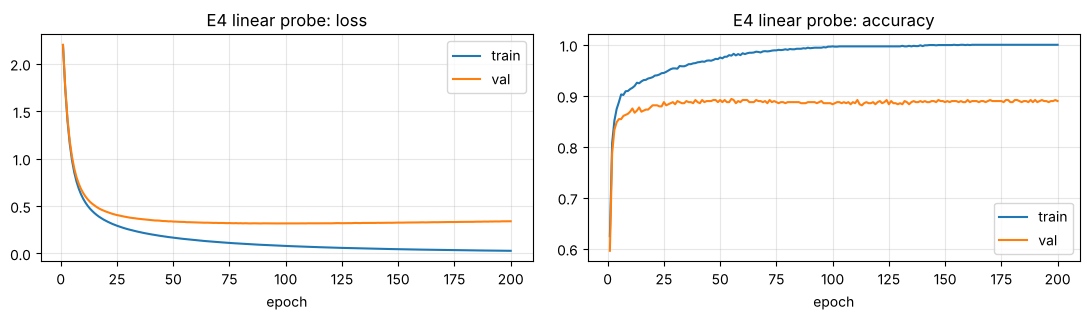

In [13]:
# E4: linear probe on frozen ImageNet ResNet-18 features
set_random_seed(SEED)
RES = 160
backbone = make_timm('resnet18', pretrained=True).to(device).eval()

@torch.inference_mode()
def extract(imgs, labels):
    dl = DataLoader(CachedDataset(imgs, labels, eval_transform(RES, True)), batch_size=128)
    feats = [backbone.forward_head(backbone.forward_features(x.to(device)), pre_logits=True).cpu() for x, _ in dl]
    return torch.cat(feats), torch.as_tensor(labels)

t0 = time.time()
ftr, ytr = extract(tr_imgs, tr_labels); fva, yva = extract(va_imgs, va_labels)
probe = nn.Linear(ftr.shape[1], num_classes)
opt_p = optim.AdamW(probe.parameters(), lr=1e-3, weight_decay=1e-3)
hist_p = {k: [] for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc']}
best = (-1, None, -1)
for ep in range(1, E(200) + 1):
    perm = torch.randperm(len(ftr))
    for i in range(0, len(ftr), 128):
        b = perm[i:i+128]; opt_p.zero_grad(); F.cross_entropy(probe(ftr[b]), ytr[b]).backward(); opt_p.step()
    with torch.no_grad():
        lt, lv = probe(ftr), probe(fva)
        for k, v in zip(hist_p, [F.cross_entropy(lt, ytr).item(), (lt.argmax(1) == ytr).float().mean().item(),
                                 F.cross_entropy(lv, yva).item(), (lv.argmax(1) == yva).float().mean().item()]):
            hist_p[k].append(v)
    if hist_p['val_acc'][-1] > best[0]:
        best = (hist_p['val_acc'][-1], copy.deepcopy(probe.state_dict()), ep)
s = {'hist': hist_p, 'best_val_acc': best[0], 'best_epoch': best[2],
     'train_time_min': (time.time() - t0) / 60, 'final_train_acc': hist_p['train_acc'][-1]}
print(f"Linear probe: best val acc {best[0]:.4f} (epoch {best[2]}), {s['train_time_min']:.1f} min")
probe.load_state_dict(best[1])
record('E4 ResNet-18 ImageNet, linear probe', s, probe, 'Frozen backbone, train head only', res=RES, pretrained='ImageNet-1k (frozen)', aug='no',
       params_M=count_params(backbone) / 1e6)  # total model size (only the 8k head params are trained)
plot_history(s, 'E4 linear probe')
del backbone

resnet18 ImageNet-1k weights loaded: <All keys matched successfully>


[E5_resnet18_ft160] finished run found in runs/E5_resnet18_ft160.pt -> loading checkpoint and replaying its training log
[E5_resnet18_ft160] ep 01/12 | train loss 2.518 acc 0.271 | val loss 1.620 acc 0.688
[E5_resnet18_ft160] ep 02/12 | train loss 1.305 acc 0.745 | val loss 0.600 acc 0.825
[E5_resnet18_ft160] ep 03/12 | train loss 1.023 acc 0.833 | val loss 0.586 acc 0.840
[E5_resnet18_ft160] ep 04/12 | train loss 0.916 acc 0.877 | val loss 0.455 acc 0.869
[E5_resnet18_ft160] ep 05/12 | train loss 0.845 acc 0.911 | val loss 0.433 acc 0.887
[E5_resnet18_ft160] ep 06/12 | train loss 0.795 acc 0.934 | val loss 0.437 acc 0.883
[E5_resnet18_ft160] ep 07/12 | train loss 0.790 acc 0.928 | val loss 0.381 acc 0.910
[E5_resnet18_ft160] ep 08/12 | train loss 0.748 acc 0.955 | val loss 0.393 acc 0.900
[E5_resnet18_ft160] ep 09/12 | train loss 0.740 acc 0.954 | val loss 0.386 acc 0.912
[E5_resnet18_ft160] ep 10/12 | train loss 0.715 acc 0.963 | val loss 0.387 acc 0.910
[E5_resnet18_ft160] ep 11/12 

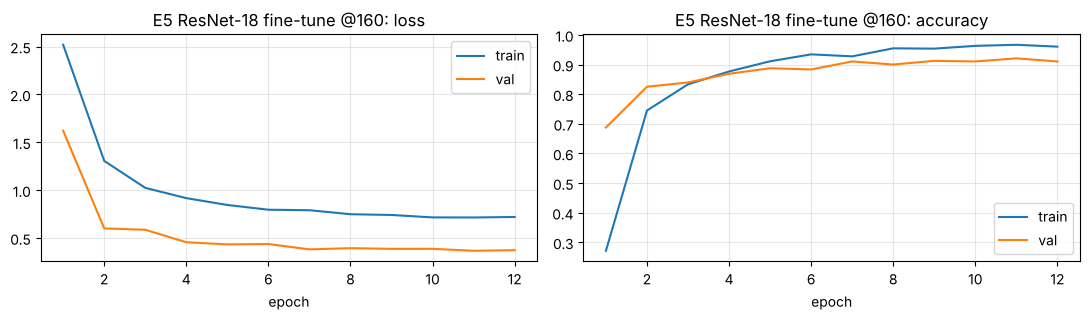

In [14]:
# E5: full fine-tuning of ImageNet ResNet-18
FT = dict(lr=5e-4, head_lr_mult=10, opt='adamw', weight_decay=0.05, schedule='onecycle', label_smoothing=0.1)
set_random_seed(SEED)
tl, vl = make_loaders(160, augment=True, pretrained=True, batch_size=32)
m = make_timm('resnet18', pretrained=True)
m, s = train_model(m, tl, vl, epochs=E(12), tag='E5_resnet18_ft160', **FT)
record('E5 ResNet-18 ImageNet, full fine-tune', s, m, 'All layers fine-tuned, E3 recipe', res=160, pretrained='ImageNet-1k', aug='yes')
plot_history(s, 'E5 ResNet-18 fine-tune @160')

[E6_resnet18_scratch160] finished run found in runs/E6_resnet18_scratch160.pt -> loading checkpoint and replaying its training log
[E6_resnet18_scratch160] ep 01/12 | train loss 2.711 acc 0.120 | val loss 2.492 acc 0.171
[E6_resnet18_scratch160] ep 02/12 | train loss 2.495 acc 0.221 | val loss 2.411 acc 0.260
[E6_resnet18_scratch160] ep 03/12 | train loss 2.245 acc 0.315 | val loss 2.211 acc 0.298
[E6_resnet18_scratch160] ep 04/12 | train loss 2.030 acc 0.410 | val loss 1.690 acc 0.429
[E6_resnet18_scratch160] ep 05/12 | train loss 1.889 acc 0.464 | val loss 1.420 acc 0.554
[E6_resnet18_scratch160] ep 06/12 | train loss 1.780 acc 0.503 | val loss 1.351 acc 0.554
[E6_resnet18_scratch160] ep 07/12 | train loss 1.702 acc 0.545 | val loss 1.253 acc 0.600
[E6_resnet18_scratch160] ep 08/12 | train loss 1.649 acc 0.555 | val loss 1.161 acc 0.650
[E6_resnet18_scratch160] ep 09/12 | train loss 1.590 acc 0.590 | val loss 1.099 acc 0.656
[E6_resnet18_scratch160] ep 10/12 | train loss 1.538 acc 0.

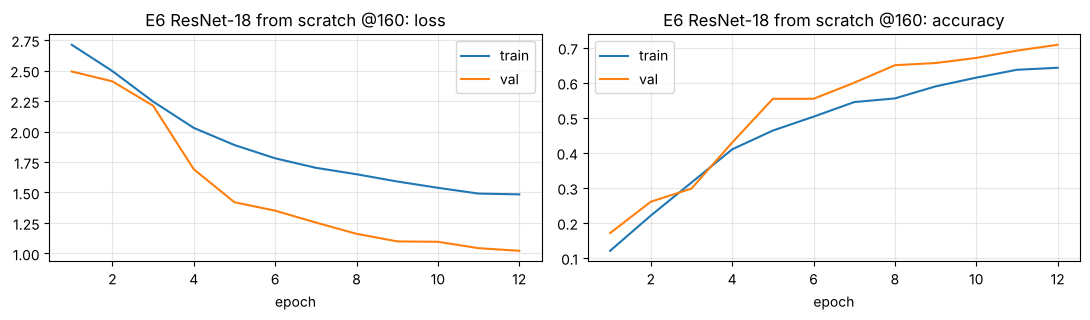

In [15]:
# E6: control — identical to E5 but random initialisation
set_random_seed(SEED)
tl, vl = make_loaders(160, augment=True, pretrained=True, batch_size=32)
m = make_timm('resnet18', pretrained=False)
m, s = train_model(m, tl, vl, epochs=E(12), tag='E6_resnet18_scratch160', **FT)
record('E6 ResNet-18 random init (control)', s, m, 'Same as E5 without pretraining', res=160, pretrained='no', aug='yes')
plot_history(s, 'E6 ResNet-18 from scratch @160')

## 9. Experiment 7 — Smaller model: EfficientNet-B0

**Question.** Can a smaller, more efficient CNN do almost as well? EfficientNet-B0 has ~4.0M parameters (vs 11.2M) and ~0.4 vs ~1.8 GFLOPs at 224 px. Pretrained weights: `efficientnet_b0.ra_in1k` (timm, ImageNet-1k). Same recipe and resolution as E5.

efficientnet_b0 ImageNet-1k weights loaded: <All keys matched successfully>


[E7_effb0_ft160] finished run found in runs/E7_effb0_ft160.pt -> loading checkpoint and replaying its training log
[E7_effb0_ft160] ep 01/12 | train loss 1.847 acc 0.557 | val loss 0.457 acc 0.860
[E7_effb0_ft160] ep 02/12 | train loss 1.152 acc 0.795 | val loss 0.762 acc 0.783
[E7_effb0_ft160] ep 03/12 | train loss 1.072 acc 0.820 | val loss 0.601 acc 0.831
[E7_effb0_ft160] ep 04/12 | train loss 0.873 acc 0.904 | val loss 0.449 acc 0.871
[E7_effb0_ft160] ep 05/12 | train loss 0.832 acc 0.918 | val loss 0.443 acc 0.890
[E7_effb0_ft160] ep 06/12 | train loss 0.742 acc 0.952 | val loss 0.415 acc 0.910
[E7_effb0_ft160] ep 07/12 | train loss 0.711 acc 0.959 | val loss 0.325 acc 0.929
[E7_effb0_ft160] ep 08/12 | train loss 0.677 acc 0.973 | val loss 0.340 acc 0.921
[E7_effb0_ft160] ep 09/12 | train loss 0.650 acc 0.983 | val loss 0.331 acc 0.919
[E7_effb0_ft160] ep 10/12 | train loss 0.641 acc 0.981 | val loss 0.318 acc 0.929
[E7_effb0_ft160] ep 11/12 | train loss 0.630 acc 0.988 | val loss

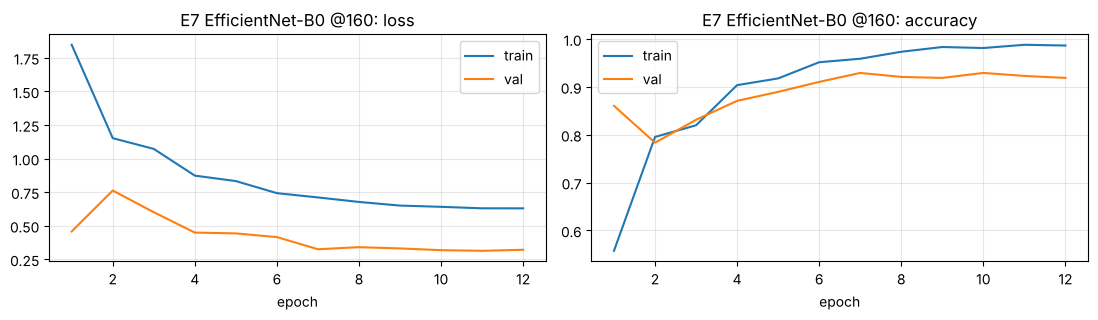

In [16]:
set_random_seed(SEED)
tl, vl = make_loaders(160, augment=True, pretrained=True, batch_size=32)
m = make_timm('efficientnet_b0', pretrained=True)
m, s = train_model(m, tl, vl, epochs=E(12), tag='E7_effb0_ft160', **{**FT, 'lr': 1e-3})
record('E7 EfficientNet-B0 ImageNet, fine-tune', s, m, 'Smaller CNN, same recipe (lr 1e-3)', res=160, pretrained='ImageNet-1k', aug='yes')
plot_history(s, 'E7 EfficientNet-B0 @160')

## 10. Experiment 8 — Higher resolution (224 px)

**Question.** Does increasing input resolution from 160 to 224 (≈2× compute per image) help enough to justify the cost? ResNet-18 was pretrained at 224, so this also removes a train/pretrain resolution mismatch. Everything else identical to E5.

resnet18 ImageNet-1k weights loaded: <All keys matched successfully>


[E8_resnet18_ft224] ep 01/12 | train loss 2.532 acc 0.276 | val loss 1.668 acc 0.742 | 198s


[E8_resnet18_ft224] ep 02/12 | train loss 1.242 acc 0.773 | val loss 0.537 acc 0.842 | 390s


[E8_resnet18_ft224] ep 03/12 | train loss 0.966 acc 0.851 | val loss 0.504 acc 0.848 | 588s


[E8_resnet18_ft224] ep 04/12 | train loss 0.854 acc 0.916 | val loss 0.425 acc 0.883 | 785s


...

[E8_resnet18_ft224] ep 09/12 | train loss 0.701 acc 0.971 | val loss 0.351 acc 0.910 | 1737s


[E8_resnet18_ft224] ep 10/12 | train loss 0.693 acc 0.976 | val loss 0.334 acc 0.912 | 1928s


[E8_resnet18_ft224] ep 11/12 | train loss 0.684 acc 0.978 | val loss 0.332 acc 0.917 | 2118s


[E8_resnet18_ft224] ep 12/12 | train loss 0.680 acc 0.978 | val loss 0.340 acc 0.915 | 2310s


[E8_resnet18_ft224] best val acc 0.9167 at epoch 11 | 38.5 min


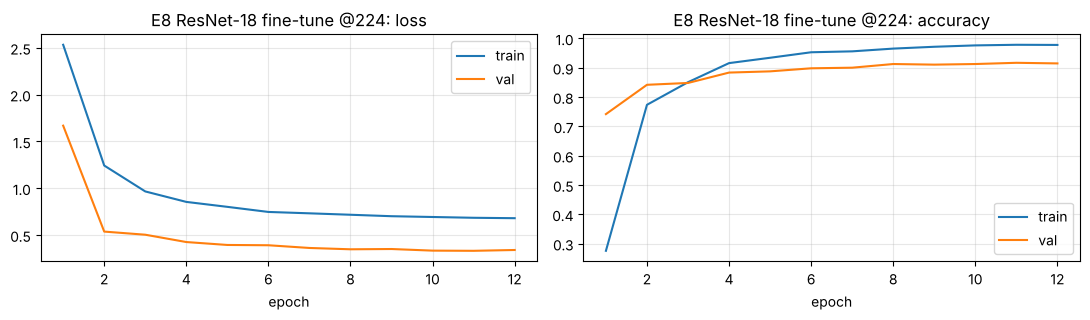

In [17]:
set_random_seed(SEED)
tl, vl = make_loaders(224, augment=True, pretrained=True, batch_size=32)
m = make_timm('resnet18', pretrained=True)
m, s = train_model(m, tl, vl, epochs=E(12), tag='E8_resnet18_ft224', **FT)
record('E8 ResNet-18 ImageNet, fine-tune @224', s, m, 'E5 at 224 px', res=224, pretrained='ImageNet-1k', aug='yes')
plot_history(s, 'E8 ResNet-18 fine-tune @224')

## 11. Experiment summary (validation only)

,Experiment,Res,Pretrained,Aug,Params (M),Best epoch,Final train acc,Val acc,"Train time (min, CPU)",Change
0,E0 Starter TNet (64px),64,no,no,0.06,6,0.994,0.4833,0.5,Starter baseline
1,"E1 SceneCNN (BN, GAP)",64,no,no,1.18,40,0.992,0.8042,15.0,"Deeper CNN, same recipe as E0"
2,E2 + augmentation,64,no,yes,1.18,38,0.830,0.8125,16.0,RandomResizedCrop + hflip + jitter
3,E3 + AdamW/one-cycle/LS,64,no,yes,1.18,39,0.919,0.8479,15.7,"AdamW wd=0.05, one-cycle (max 3e-3), LS=0.1"
4,"E4 ResNet-18 ImageNet, linear probe",160,ImageNet-1k (frozen),no,11.18,55,1.000,0.8938,0.9,"Frozen backbone, train head only"
5,"E5 ResNet-18 ImageNet, full fine-tune",160,ImageNet-1k,yes,11.18,11,0.960,0.9208,15.8,"All layers fine-tuned, E3 recipe"
6,E6 ResNet-18 random init (control),160,no,yes,11.18,12,0.643,0.7083,16.0,Same as E5 without pretraining
7,"E7 EfficientNet-B0 ImageNet, fine-tune",160,ImageNet-1k,yes,4.03,7,0.986,0.9292,17.9,"Smaller CNN, same recipe (lr 1e-3)"
8,"E8 ResNet-18 ImageNet, fine-tune @224",224,ImageNet-1k,yes,11.18,11,0.978,0.9167,38.5,E5 at 224 px


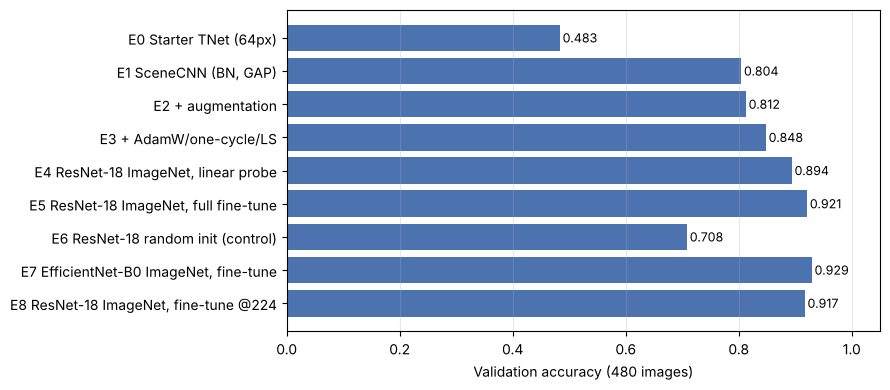

In [18]:
rows = []
for name, r in RESULTS.items():
    rows.append({'Experiment': name, 'Res': r['res'], 'Pretrained': r['pretrained'], 'Aug': r['aug'],
                 'Params (M)': round(r['params_M'], 2), 'Best epoch': r['best_epoch'],
                 'Final train acc': round(r['final_train_acc'], 3),
                 'Val acc': round(r['best_val_acc'], 4), 'Train time (min, CPU)': round(r['train_time_min'], 1),
                 'Change': r['notes']})
summary_df = pd.DataFrame(rows)
summary_df.to_csv(RUN_DIR / 'experiment_summary.csv', index=False)
display(summary_df)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(summary_df['Experiment'][::-1], summary_df['Val acc'][::-1], color='#4C72B0')
for i, v in enumerate(summary_df['Val acc'][::-1]):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlim(0, 1.05); ax.set_xlabel('Validation accuracy (480 images)'); ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()

## 12. Model selection (validation only) and test-time augmentation check

The final model is the experiment with the highest validation accuracy. I also check on the **validation set** whether averaging predictions over the original and horizontally flipped image (TTA) helps; it is used on the test set only if it helps on validation.

In [19]:
CKPT = {'E5 ResNet-18 ImageNet, full fine-tune': ('E5_resnet18_ft160', 'resnet18', 160),
        'E7 EfficientNet-B0 ImageNet, fine-tune': ('E7_effb0_ft160', 'efficientnet_b0', 160),
        'E8 ResNet-18 ImageNet, fine-tune @224': ('E8_resnet18_ft224', 'resnet18', 224)}
best_name = max(CKPT, key=lambda k: RESULTS[k]['best_val_acc'])
tag, arch, RES = CKPT[best_name]
print('Selected model (by validation accuracy):', best_name)

final_model = make_timm(arch, pretrained=False)
final_model.load_state_dict(torch.load(RUN_DIR / f'{tag}.pt', map_location='cpu'))
final_model = final_model.to(device).eval()

vl_final = DataLoader(CachedDataset(va_imgs, va_labels, eval_transform(RES, True)), batch_size=128)
_, va_plain, _ = evaluate(final_model, vl_final, tta=False)
_, va_tta, _ = evaluate(final_model, vl_final, tta=True)
USE_TTA = va_tta > va_plain
print(f'Validation acc: plain {va_plain:.4f} | flip-TTA {va_tta:.4f} -> use TTA: {USE_TTA}')

Selected model (by validation accuracy): E7 EfficientNet-B0 ImageNet, fine-tune


Validation acc: plain 0.9292 | flip-TTA 0.9292 -> use TTA: False


## 13. Final test evaluation (run once)

In [20]:
test_loader = DataLoader(CachedDataset(test_imgs, test_labels, eval_transform(RES, True)), batch_size=128)
test_loss, test_acc, test_logits = evaluate(final_model, test_loader, tta=USE_TTA)
test_pred = test_logits.argmax(1).numpy()
print(f'Selected model: {best_name} (TTA={USE_TTA})')
print(f'Validation accuracy: {max(va_plain, va_tta):.4f}')
print(f'FINAL TEST ACCURACY: {test_acc:.4f}  ({int(round(test_acc*len(test_labels)))}/{len(test_labels)})  | test loss {test_loss:.4f}')

# For reference only (NOT used for selection): best from-scratch model on the test set
scratch_loader = DataLoader(CachedDataset(test_imgs, test_labels, eval_transform(64, False)), batch_size=128)
_, scratch_test_acc, _ = evaluate(scratch_best.to(device), scratch_loader)
print(f'(Reference) best from-scratch SceneCNN (E3) test accuracy: {scratch_test_acc:.4f}')

Selected model: E7 EfficientNet-B0 ImageNet, fine-tune (TTA=False)
Validation accuracy: 0.9292
FINAL TEST ACCURACY: 0.9150  (366/400)  | test loss 0.3832


(Reference) best from-scratch SceneCNN (E3) test accuracy: 0.8150


## 14. Per-class analysis — which classes are hardest?

              precision    recall  f1-score   support

     Bedroom      1.000     1.000     1.000        25
       Coast      0.923     0.960     0.941        25
      Flower      1.000     1.000     1.000        25
      Forest      1.000     0.680     0.810        25
     Highway      1.000     1.000     1.000        25
  Industrial      0.846     0.880     0.863        25
  InsideCity      0.957     0.880     0.917        25
     Kitchen      0.875     0.840     0.857        25
  LivingRoom      0.852     0.920     0.885        25
    Mountain      1.000     0.720     0.837        25
      Office      0.962     1.000     0.980        25
 OpenCountry      0.590     0.920     0.719        25
       Store      0.920     0.920     0.920        25
      Street      0.962     1.000     0.980        25
      Suburb      1.000     1.000     1.000        25
TallBuilding      1.000     0.920     0.958        25

    accuracy                          0.915       400
   macro avg      0.930   

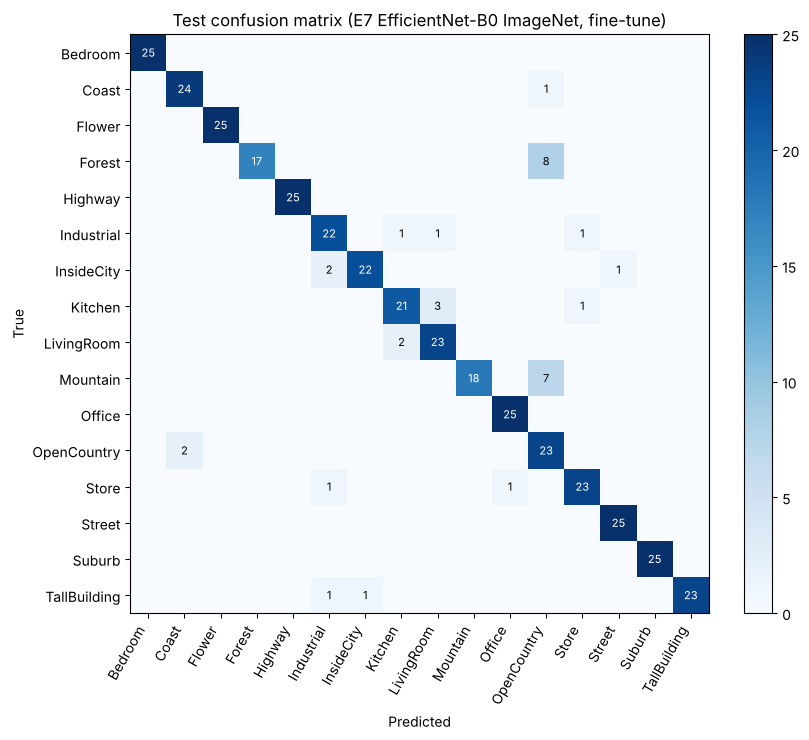

Per-class test accuracy (lowest first):
Forest          0.68
Mountain        0.72
Kitchen         0.84
Industrial      0.88
InsideCity      0.88
Store           0.92
LivingRoom      0.92
OpenCountry     0.92
TallBuilding    0.92
Coast           0.96
Bedroom         1.00
Flower          1.00
Highway         1.00
Office          1.00
Street          1.00
Suburb          1.00

Most frequent confusions (count, true -> predicted):
  8: Forest -> OpenCountry
  7: Mountain -> OpenCountry
  3: Kitchen -> LivingRoom
  2: OpenCountry -> Coast
  2: LivingRoom -> Kitchen
  2: InsideCity -> Industrial


In [21]:
print(classification_report(test_labels, test_pred, target_names=class_names, digits=3))
cm = confusion_matrix(test_labels, test_pred)
fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names, rotation=60, ha='right')
ax.set_yticks(range(num_classes)); ax.set_yticklabels(class_names)
for i in range(num_classes):
    for j in range(num_classes):
        if cm[i, j]: ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > 12 else 'black', fontsize=8)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'Test confusion matrix ({best_name})')
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

per_class = pd.Series(cm.diagonal() / cm.sum(1), index=class_names).sort_values()
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = sorted(((off[i, j], class_names[i], class_names[j]) for i in range(num_classes) for j in range(num_classes) if off[i, j]), reverse=True)[:6]
print('Per-class test accuracy (lowest first):'); print(per_class.round(2).to_string())
print('\nMost frequent confusions (count, true -> predicted):')
for c, a, b in pairs:
    print(f'  {c}: {a} -> {b}')

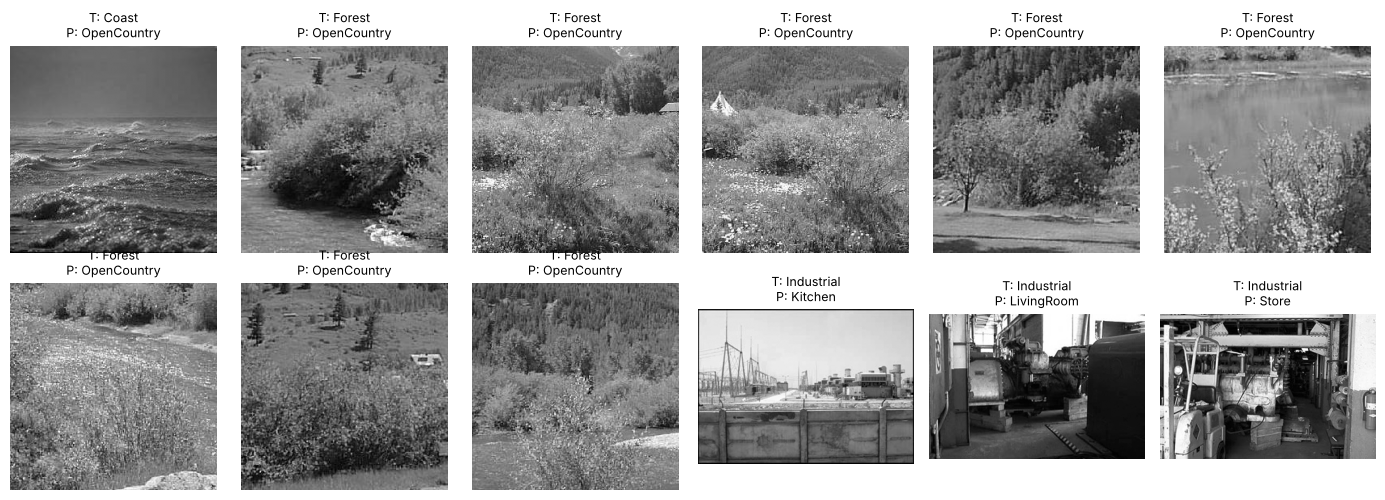

In [22]:
# Examples of misclassified test images
wrong = np.where(test_pred != test_labels)[0]
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, i in zip(axes.flat, wrong[:12]):
    ax.imshow(test_imgs[i], cmap='gray'); ax.axis('off')
    ax.set_title(f'T: {class_names[test_labels[i]]}\nP: {class_names[test_pred[i]]}', fontsize=9)
for ax in axes.flat[len(wrong[:12]):]: ax.axis('off')
plt.tight_layout(); plt.show()

## 15. Predictions for the unlabeled `test2` images

In [23]:
t2_paths = sorted(TEST2_ROOT.glob('*.jpg'), key=lambda p: int(p.stem.split('_')[-1]))
t2_imgs = []
for p in t2_paths:
    with Image.open(p) as im:
        t2_imgs.append(resize_short(im.convert('L')))
t2_loader = DataLoader(CachedDataset(t2_imgs, np.zeros(len(t2_imgs), dtype=int), eval_transform(RES, True)), batch_size=128)
_, _, t2_logits = evaluate(final_model, t2_loader, tta=USE_TTA)
pred_df = pd.DataFrame({'image': [p.name for p in t2_paths], 'predicted_label': [class_names[i] for i in t2_logits.argmax(1)]})
pred_df.to_csv('test2_predictions.csv', index=False)
print(pred_df.head()); print(pred_df['predicted_label'].value_counts().to_string())

         image predicted_label
0  image_0.jpg      InsideCity
1  image_1.jpg          Suburb
2  image_2.jpg         Bedroom
3  image_3.jpg      Industrial
4  image_4.jpg      LivingRoom
predicted_label
LivingRoom      36
OpenCountry     29
Flower          27
Industrial      26
Highway         26
InsideCity      25
Suburb          25
Bedroom         25
Street          25
Mountain        25
TallBuilding    23
Forest          23
Coast           22
Kitchen         21
Office          21
Store           21


## 16. Analysis and conclusions

### Final result
| | |
|---|---|
| **Selected model** | EfficientNet-B0 (ImageNet-1k pretrained, `timm` RandAugment weights), all layers fine-tuned, grayscale input at 160×160 |
| **Validation accuracy** (480 held-out training images, stratified) | **92.9 %** |
| **Test accuracy** (400 images, evaluated once) | **91.5 %** (366 / 400) |
| Starter TNet on the same validation split | 48.3 % |

Model selection used validation accuracy only; the test set was evaluated once, after the model was chosen. Flip-TTA was checked on validation, gave no gain (92.9 % both ways), and was therefore not used.

### Experimental journey (validation accuracy)
| Experiment | What changed | Val acc | Observation |
|---|---|---:|---|
| E0 Starter TNet | – | 48.3 % | Train acc 99 %, val loss rises after epoch ~6: one conv layer memorises the data through a 3,600×16 linear layer but learns no scene-level features. |
| E1 SceneCNN | 8 conv layers + BatchNorm + global average pooling | 80.4 % | **Largest single gain (+32 pts).** Architecture/receptive field was the main bottleneck. Still overfits (train 99 %). |
| E2 + augmentation | random-resized crop, h-flip, brightness/contrast jitter | 81.3 % | Overfitting gap closes (train 83 %), val loss improves 0.78 → 0.57, but accuracy barely moves and is very noisy epoch to epoch (67–81 % in the last 5 epochs) with a constant LR. |
| E3 + training strategy | AdamW (wd 0.05), one-cycle LR, label smoothing 0.1 | 84.8 % | +3.5 pts and stable curves (83–85 % over the last 5 epochs). Augmentation only paid off once the LR was annealed. |
| E4 ResNet-18 linear probe | frozen ImageNet features, train 16-way head only | 89.4 % | Off-the-shelf ImageNet features already beat the best from-scratch model, in < 1 CPU-minute. |
| E5 ResNet-18 fine-tune @160 | all layers fine-tuned, E3 recipe | 92.1 % | +2.7 pts over the frozen backbone. |
| E6 ResNet-18 random init | same as E5 without pretraining | 70.8 % | Same architecture and recipe, −21 pts: with 1,920 images the gain comes from the initialisation, not from the architecture. |
| E7 EfficientNet-B0 fine-tune @160 | smaller CNN (4.0 M vs 11.2 M params) | **92.9 %** | Matches/slightly exceeds ResNet-18 with ~1/3 of the parameters. **Selected.** |
| E8 ResNet-18 fine-tune @224 | E5 at higher resolution | 91.7 % | No gain over 160 px at 2.4× the training time. |

### What mattered
1. **Architecture depth + BatchNorm + GAP** (48 → 80 %): the starter was mostly limited by its receptive field, not by its training recipe.
2. **ImageNet initialisation** (71 → 92 % for the identical ResNet-18 and recipe): by far the most important choice in the small-data regime. Even grayscale scenes benefit from features learned on colour object photos.
3. **LR schedule + weight decay + label smoothing** (81 → 85 % from scratch): smaller, but it also made model selection much more trustworthy because the validation curve stopped jumping around.
4. **Data handling:** converting everything to grayscale removes the "RGB ⇒ Flower" shortcut found in Section 2.

### Failure analysis — things that did not work as expected
* **Higher resolution (E8).** *Expectation:* 224 px matches the resolution ResNet-18 was pretrained at and preserves finer texture, so it should help. *Result:* 91.7 % vs 92.1 % at 160 px, for 38.5 vs 15.8 CPU-minutes. *Interpretation:* the source images are only ~256 px (mostly 256×256 or ~300×220) and scene categories are defined by coarse global layout, so up-sampling adds compute but no information. The 0.4-pt difference is 2 validation images — well inside the noise — so the honest conclusion is "no measurable benefit", not "224 is worse".
* **Augmentation alone (E2).** *Expectation:* the overfit E1 model should gain several points. *Result:* +0.8 pts (4 images) and unstable validation accuracy. *Lesson:* with a constant LR of 2e-3 the augmented model was under-trained/noisy rather than overfit (train acc 83 %); the benefit only appeared with a decaying schedule (E3). Regularisation and optimisation have to be tuned together.
* **Deeper network from scratch (E6).** A ResNet-18 from random init (70.8 %) is *worse* than the 10× smaller SceneCNN (84.8 %). Caveat: E6 had only 12 epochs and was still under-fitting (train acc 64 %), so this is partly an epoch-budget effect, not purely a capacity effect — it would need a longer run to separate the two.
* **Flip TTA.** No change on validation (92.9 % → 92.9 %), so it was dropped.

### Which classes are hard?
On the test set, 11 of 16 classes have recall ≥ 92 % and six are at 100 % (Bedroom, Flower, Highway, Office, Street, Suburb). The errors are concentrated in the **natural outdoor scenes**: *Forest → OpenCountry* (8) and *Mountain → OpenCountry* (7) account for 15 of the 34 errors, which is why OpenCountry has precision of only 0.59 while its recall is 0.92. These categories overlap semantically (a field with a tree line, hills on the horizon). The second cluster is indoor rooms (*Kitchen ↔ LivingRoom*, 5 errors). This suggests the next experiment should target that boundary (e.g. longer training, class-balanced checks, or an ensemble of E5 + E7) rather than more generic regularisation.

### Caveats on the numbers
* **Single seed, small validation set.** With 480 validation images, one standard error at ~92 % is about ±1.2 pts, so E5, E7 and E8 (92.1 / 92.9 / 91.7 %) are **not statistically distinguishable**. EfficientNet-B0 was selected because it is the top validation score *and* the smallest model; the claim "B0 is better than ResNet-18" is not supported, only "B0 is at least as good with fewer parameters". Repeating with 3 seeds or 5-fold CV would be needed to rank them.
* **Val → test gap** (92.9 → 91.5 %) is within one standard error of the test estimate (±1.4 pts on 400 images).
* **Compute.** Everything ran on 2 CPU cores, so pretrained models got only 12 epochs and from-scratch models ran at 64 px. E6 in particular is under-trained. Training time per run is listed in the summary table for an accuracy–efficiency comparison.
* **Execution note.** The cloud machine restarted during the long E8 run. Runs E0–E7 had already finished and saved their checkpoints and per-epoch logs, so on re-execution those cells loaded the saved run and replayed its log (see "finished run found" in the cell output) instead of retraining; E4 and E8 and all evaluation cells were executed fresh. Reported training times for E0–E7 are from the original runs.

### Pretraining disclosure
* `resnet18.a1_in1k` and `efficientnet_b0.ra_in1k` (from `timm`), both pretrained on **ImageNet-1k** classification only.
* E4: backbone frozen, only the new 16-way linear head trained. E5/E7/E8: **all** parameters fine-tuned (backbone LR 5e-4 for ResNet-18 / 1e-3 for B0, head LR 10× higher).
* No CLIP, DINO, ViT or VLM models were used.

### Final recipe (E7)
EfficientNet-B0, ImageNet-1k init · grayscale replicated to 3 channels, 160×160 · RandomResizedCrop(scale 0.35–1) + horizontal flip + brightness/contrast jitter · AdamW, weight decay 0.05, backbone LR 1e-3, head LR 1e-2 · one-cycle schedule (15 % warm-up, cosine decay) · batch 32, 12 epochs · cross-entropy with label smoothing 0.1 · checkpoint with best validation accuracy · seed 0. Checkpoint: `runs/E7_effb0_ft160.pt`.